# 📌 Problem Definition

> - 💼 Business Requirement: The bank aims to reduce the risk of financial loss due to loan defaults (borrowers failing to repay).
> - 🎯 Objective: To predict whether a borrower is likely to default or pay on time → to assist the credit team in the decision-making process.
> - 📊 Output: A credit risk prediction model + an interactive dashboard for monitoring.

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris  
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
from scipy import interp    
from itertools import cycle
from sklearn.model_selection import GridSearchCV

In [31]:
# Membuka file dataset menggunakan pandas

df = pd.read_csv('financial_loan_dataset.csv')
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


**🔍 Exploratory Data Analysis (EDA)**

The initial stage of data analysis to understand the contents and characteristics of the dataset. EDA helps us observe data distributions, patterns, relationships between variables, and detect anomalies.

✅ Essentially, EDA provides early insights before we proceed to the modeling stage.

> *OVERALL GOAL:* > - Gain an understanding of which variables are important, identify relationships between variables, and visualize the data.

In [19]:
#Drop other classes for the target variable

df_loan = df[df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Current'])]

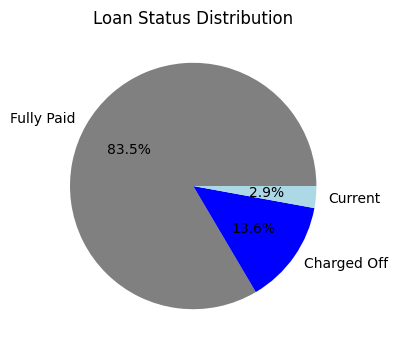

In [20]:
#Bar chart for target variable loan_status
loan_status_counts = df_loan['loan_status'].value_counts()

plt.figure(figsize=(8, 4))
plt.pie(loan_status_counts.values, labels=loan_status_counts.index, autopct='%1.1f%%', colors=['grey','blue',"lightblue"])
plt.title('Loan Status Distribution')
plt.show()  

**🔗 Feature Correlation & Visualization**


> *🎯 Note* >
> **Default** in the context of loans means failure to repay or the borrower’s inability to meet loan payment obligations as agreed. Usually, a default is defined as:
> - Failure to pay installments for a specific period (e.g., 90 consecutive days),
> - Arrears that are past due,
> - Or loans categorized as “charge-off” (a loss for the bank because the debt is considered uncollectible).

📊 In the loan_status dataset, the default category represents borrowers who are unable to continue their loan payments → this becomes the primary target for prediction, as the bank aims to reduce the risk of loss from cases of failure to pay.

**🧩 `loan_amount` & `loan_status`**

- `loan_amount`: The amount of the loan applied for by the borrower. If the credit department reduces the loan amount at any point, it will be reflected in this value.
- `loan_status`: Measures the success rate or status of the loan.

> ❓ *Questions:* >- Do borrowers with larger loan amounts default more frequently?
>- Is there a specific loan amount threshold that is more prone to default?

C:\Users\Dian Sukma\AppData\Local\Temp\ipykernel_6312\2389426044.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="loan_status", y="loan_amount", data=df, palette="Set2")


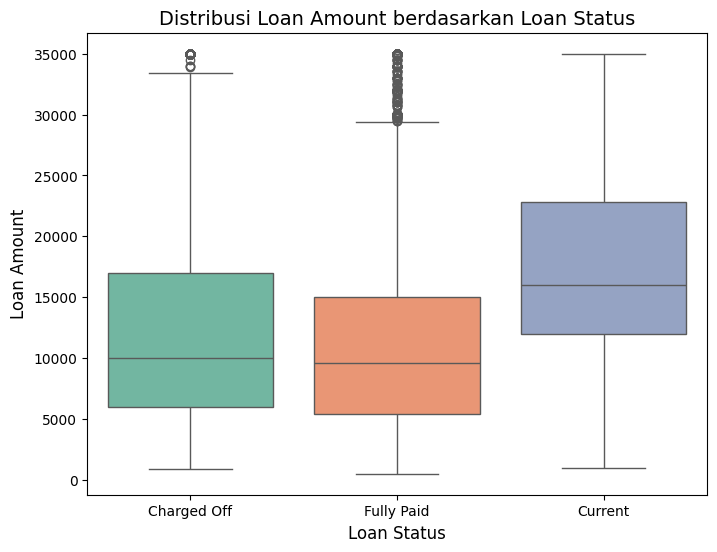

In [9]:
plt.figure(figsize=(8,6))
sns.boxplot(x="loan_status", y="loan_amount", data=df, palette="Set2")

# Tambahan agar lebih informatif
plt.title("Distribusi Loan Amount berdasarkan Loan Status", fontsize=14)
plt.xlabel("Loan Status", fontsize=12)
plt.ylabel("Loan Amount", fontsize=12)
plt.show()

**🔄 Correlation & Hypothesis → Larger loans tend to have a higher risk of default.**

**📝 Findings**
>- Yes, the median `loan_amount` in the default group is higher compared to the fully paid group.
>- Loans > 20,000 tend to show a spike in defaults.


**💡 Insight:** The bank needs to establish a maximum loan amount threshold for high-risk customers.

-------------------------------------------------------------------------------------------------------

**🧩 `int_rate` & `loan_status`**

- `int_rate`: The interest rate of the loan.
- `loan_status`: Measures the success rate or status of the loan.

> ❓ *Questions:* >- Are high interest rates identical to more frequent defaults?
>- How is the interest rate distributed in the default group vs. the fully paid group?

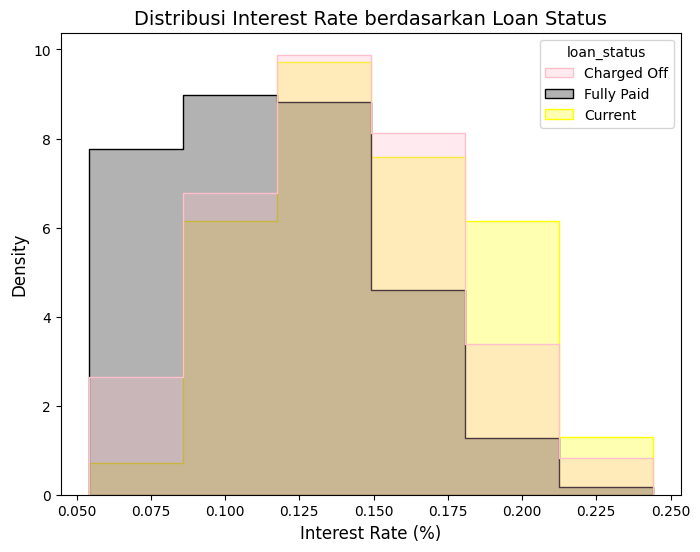

In [10]:
plt.figure(figsize=(8,6))
sns.histplot(
    data=df, 
    x="int_rate", 
    hue="loan_status", 
    element="step",   # garis step agar overlap terlihat
    stat="density", 
    common_norm=False, 
    bins=6,
    palette={"Fully Paid": "black", "Charged Off": "pink", "Current": "yellow"},
    alpha=0.3       # transparansi supaya tumpang tindih terlihat
)

plt.title("Distribusi Interest Rate berdasarkan Loan Status", fontsize=14)
plt.xlabel("Interest Rate (%)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.show()

**🔄 Correlation & Hypothesis → Positive → higher interest rates → increased risk of default.**

**📝 Findings**
>- Yes, defaults are dominated by borrowers with interest rates above 15%.
>- Fully paid status is more common among lower interest rates (around 7–12%).

**💡 Insight:** Setting high interest rates as compensation actually increases the risk of default.

---------------------------------------------------------------------------------

**🧩 `dti` & `loan_status`**

- `dti (Debt-to-Income Ratio)`: A ratio calculated using the borrower’s total monthly debt payments on total debt obligations, excluding mortgages and the requested LC loan, divided by the borrower’s self-reported monthly income.
- `loan_status`: Measures the success rate or status of the loan.

> ❓ *Questions:* >- Does a high DTI (relatively high debt compared to income) increase the likelihood of default?
>- Is there a critical DTI value where defaults spike?

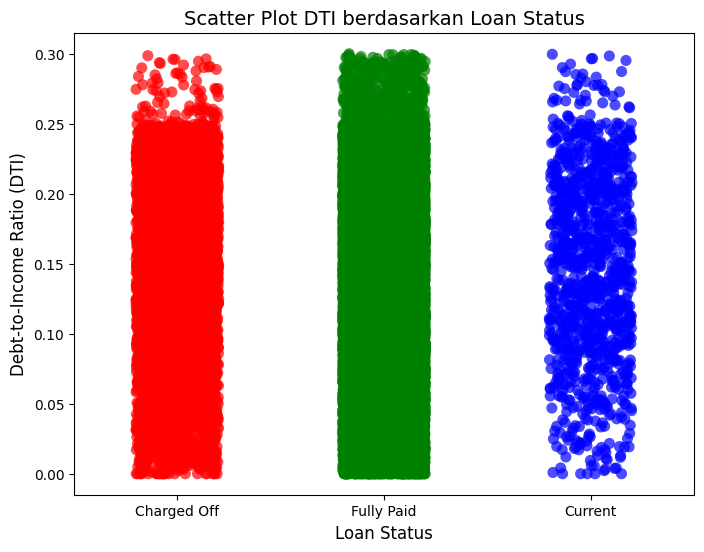

In [11]:
plt.figure(figsize=(8,6))
sns.stripplot(
    x="loan_status", 
    y="dti", 
    hue="loan_status",    # assign kategori ke hue
    data=df, 
    jitter=0.2,           # geser horizontal supaya tidak bertumpuk
    palette={"Fully Paid": "green", "Charged Off": "red", "Current": "blue"},
    size=8, 
    alpha=0.7,
    dodge=False           # tetap satu garis per kategori
)

plt.title("Scatter Plot DTI berdasarkan Loan Status", fontsize=14)
plt.xlabel("Loan Status", fontsize=12)
plt.ylabel("Debt-to-Income Ratio (DTI)", fontsize=12)
plt.legend([],[], frameon=False)  # hilangkan legend duplikat
plt.show()

**🔄 Correlation & Hypothesis → The higher the DTI, the higher the default rate.**

**📝 Findings**
>- A high DTI does not necessarily result in an immediate increase in default risk, as many borrowers with high DTI still manage to pay in full. However, it is observed that as DTI increases (approaching 0.30), the number of default cases remains significant, indicating a weak-to-moderate correlation between high DTI and default risk.
>- The critical DTI range of ≈ 0.25 – 0.30 appears more prone to default.

**💡 Insight:** DTI can be utilized as an initial filter during the credit approval process.

----------------------------------------------

**🧩 `annual_income` & `loan_status`**

- `annual_income`: The self-reported annual income provided by the borrower during registration.
- `loan_status`: Measures the success rate or status of the loan.

> ❓ *Questions:* >- Do borrowers with lower incomes default more frequently?
>- Is a high income an automatic guarantee against default?

C:\Users\Dian Sukma\AppData\Local\Temp\ipykernel_6312\216524438.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="loan_status", y="annual_income", data=df, palette="Set2")


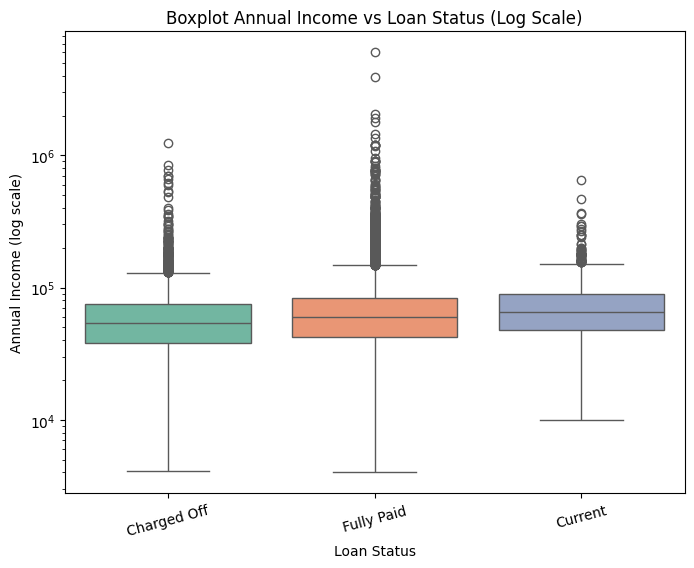

In [12]:
plt.figure(figsize=(8,6))
sns.boxplot(x="loan_status", y="annual_income", data=df, palette="Set2")
plt.yscale("log")  # pakai skala log untuk mengurangi efek outlier

plt.title("Boxplot Annual Income vs Loan Status (Log Scale)")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income (log scale)")
plt.xticks(rotation=15)
plt.show()

**🔄 Hypothesis & Correlation → Lower income tends to have a higher frequency of default.**

**📝 Findings**
>- Lower income carries a higher risk of default.
>- High income does not guarantee safety, as there are still cases of default within the high-income group.

**💡 Insight:**
>- Low income = higher default risk, but it is not the sole factor; there are still low-income borrowers who successfully repay.
>- High income ≠ a guarantee of safety, as financial behavior, total debt, and external conditions (e.g., layoffs, economic crisis) also influence defaults.
>- For credit risk analysis, Annual Income should not be treated as a standalone factor; instead, it should be combined with other ratios such as DTI (Debt-to-Income Ratio), payment history, and loan purpose.

--------------------------------------

🧩 `annual_income` & `DTI`

- `annual_income`: Pendapatan tahunan yang dilaporkan sendiri yang diberikan oleh peminjam saat pendaftaran
- `dti Debt-to-Income Ratio`: Rasio yang dihitung dengan menggunakan total pembayaran utang bulanan peminjam terhadap total kewajiban utang, tidak termasuk hipotek dan pinjaman LC yang diminta, dibagi dengan pendapatan bulanan peminjam yang dilaporkan sendiri.

> ❓*Pertanyaan:* 
>- Apakah semakin tinggi annual income membuat DTI semakin rendah?
>- Apakah ada korelasi signifikan antara annual income dan DTI?
>- Apakah ada nilai ambang income tertentu di mana DTI cenderung stabil?

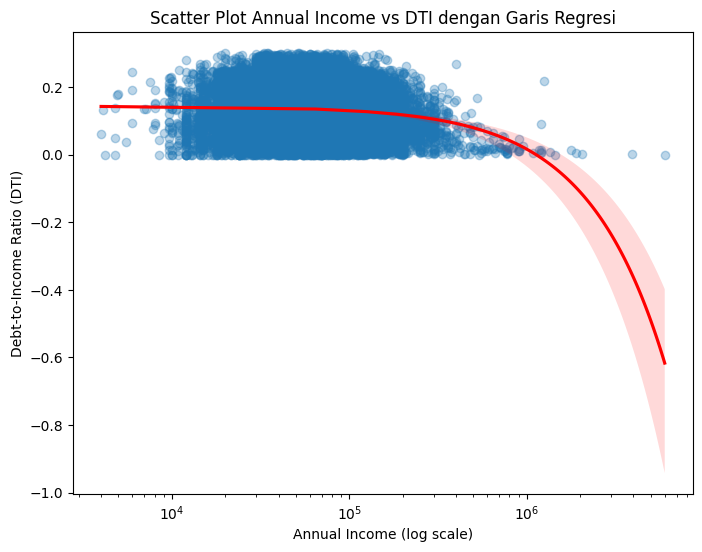

In [13]:
# Misal dataframe bernama df, dengan kolom annual_income dan dti
plt.figure(figsize=(8,6))

# Scatter plot + garis regresi
sns.regplot(
    x="annual_income", 
    y="dti", 
    data=df, 
    scatter_kws={"alpha":0.3},   # transparansi titik biar jelas
    line_kws={"color":"red"}     # garis regresi warna merah
)

# Pakai log scale biar sebaran income lebih jelas
plt.xscale("log")

plt.title("Scatter Plot Annual Income vs DTI dengan Garis Regresi")
plt.xlabel("Annual Income (log scale)")
plt.ylabel("Debt-to-Income Ratio (DTI)")
plt.show()

**🔄 Hypothesis & Correlation →**

**📝 Findings**
>- Yes, generally speaking, the higher the income, the lower the DTI.
>- There is a negative correlation between annual income and DTI, but it is not strong.
>- Yes, after annual income exceeds approximately 100k, the DTI tends to stabilize and remain low.

**💡 Insight:**
>- The correlation between annual income and DTI is negative (income increases → DTI decreases).
>- High income does help suppress DTI, but it is not the only factor involved.
>- An income threshold of approximately >100k USD marks the point where DTI becomes more stable and consistently lower.

---------------------------------

**🧩 `loan_status` & `grade`**

- `grade`: The loan grade assigned by the bank.
- `loan_status`: Measures the success rate or status of the loan.

> ❓ *Questions:* >- Do lower grades (F, G) have higher default rates?
>- Are grades A–B truly safe?

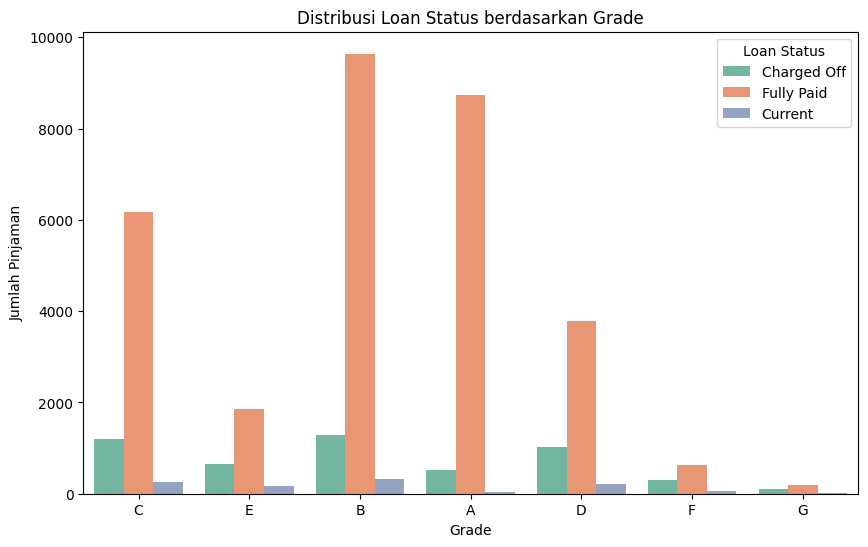

In [14]:
plt.figure(figsize=(10,6))

# Barplot: menghitung rata-rata proporsi per kombinasi grade dan loan_status
sns.countplot(
    data=df, 
    x="grade", 
    hue="loan_status",  # warnai berdasarkan loan_status
    palette="Set2"
)

plt.title("Distribusi Loan Status berdasarkan Grade")
plt.xlabel("Grade")
plt.ylabel("Jumlah Pinjaman")
plt.legend(title="Loan Status")
plt.show()

**🔄 Hypothesis & Correlation → Lower Grade → more frequent defaults.**

**📝 Findings**
>- Yes, although the total number of loans in grades F and G is small, the proportion of Charged Off (default) cases is relatively larger compared to the number of Fully Paid loans. This means that the lower the grade, the greater the risk of default.
>- Not entirely. Grades A and B do have a very dominant number of Fully Paid loans, making the default risk relatively lower. However, there are still Charged Off cases in grades A–B, so they cannot be described as “100% safe.”

**💡 Insight:**
>- Grade serves as a risk indicator: The higher the grade (A–B), the safer the loan; the lower the grade (F–G), the higher the risk of default.

----------------------------

**🧩 `loan_status` & `term`**

- `term`: The number of payments on the loan. Values are in months and can be either 36 or 60 months.
- `loan_status`: Measures the success rate or status of the loan.

> ❓ *Questions:* >- Is a longer term (60 months) more prone to default?
>- How does the default rate compare between 36 months vs. 60 months?

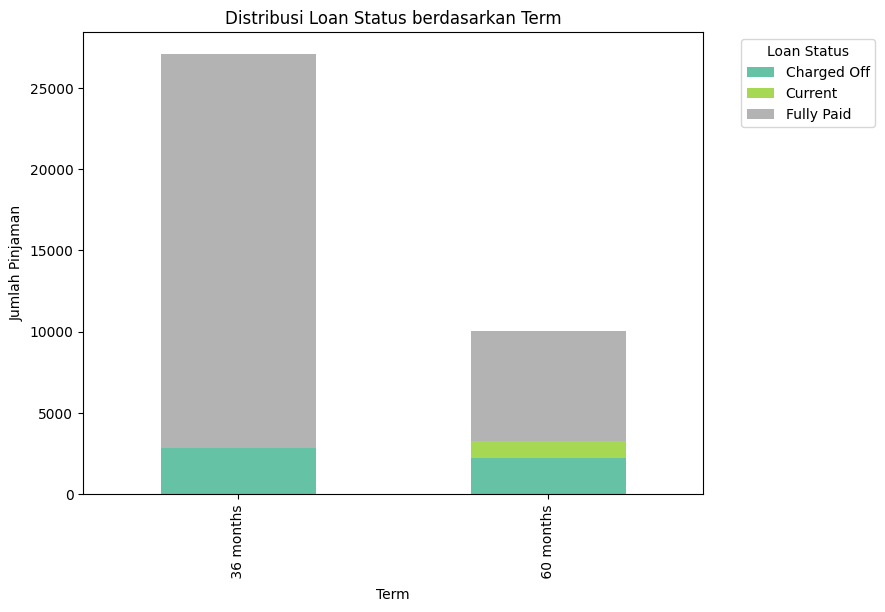

In [15]:
term_status_counts = df.groupby(["term", "loan_status"]).size().reset_index(name="count")

# Pivot agar bisa bikin stacked bar
pivot_table = term_status_counts.pivot(index="term", columns="loan_status", values="count")

# Plot stacked bar
pivot_table.plot(kind="bar", stacked=True, figsize=(8,6), colormap="Set2")

plt.title("Distribusi Loan Status berdasarkan Term")
plt.xlabel("Term")
plt.ylabel("Jumlah Pinjaman")
plt.legend(title="Loan Status", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

**🔄 Hypothesis & Correlation → The longer the term, the more frequent the default.**

**📝 Findings**
>- Yes, the 60-month term appears to be more prone to default (Charged Off) compared to the 36-month term.
>- 36 months: Defaults exist, but the proportion is smaller compared to Fully Paid loans.
>- 60 months: The proportion of defaults is larger, even approaching the number of Fully Paid and Current loans. This implies that a longer term → a higher likelihood of the borrower experiencing repayment difficulties.

**💡 Insight:**
>- A long term (60 months) offers the flexibility of smaller monthly installments, but the risk of failure to pay increases due to the longer commitment period.
>- A short term (36 months) is relatively safer, with more controlled default rates.
>- For lenders/investors, providing long-term loans (60 months) requires compensation through higher interest rates or stricter credit requirements to cover the risk of default.

-----------------------------------

**🧩 `loan_status` & `home_ownership`**

- `home_ownership`: The home ownership status provided by the borrower during registration or obtained from the credit report, such as RENT, OWN, MORTGAGE.
- `loan_status`: Measures the success rate or status of the loan.

> ❓ *Questions:* >- Are renters more at risk of default compared to homeowners?
>- Is the mortgage status (currently paying off a home) also relatively safe?

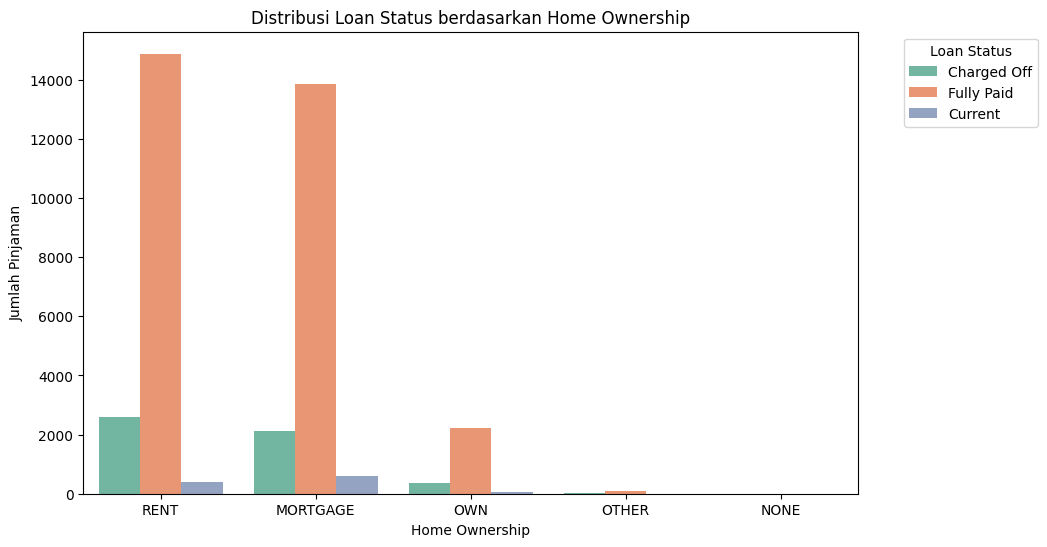

In [16]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="home_ownership", hue="loan_status", palette="Set2")

plt.title("Distribusi Loan Status berdasarkan Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Jumlah Pinjaman")
plt.legend(title="Loan Status", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

**🔄 Hypothesis & Correlation → Renters (RENT) tend to default more frequently.**

**📝 Findings**
>- Yes, renters (RENT) appear to have a higher number of defaults (Charged Off) compared to the OWN category.
>- MORTGAGE is relatively safer than RENT, although the risk still exists.

**💡 Insight:**
>- RENT is the most risky → this group tends to be more prone to failure to pay as they lack fixed assets as an indicator of financial stability.
>- MORTGAGE is quite stable → despite having a home mortgage to pay, borrowers in this category are more likely to successfully repay their loans.
>- OWN (Homeowners) → the safest category, as defaults are very low and the majority are Fully Paid.
>- From a lender's perspective, home ownership status can be used as a vital variable in assessing credit risk.

-------------------------

**🔥 Core Insights & Conclusions 🔥**

>- 🔑 `Core Risk Predictors`: DTI, Grade, Term.
>- 🧩 `Supporting Predictors`: Loan Amount, Interest Rate, Home Ownership.
>- 💰 `Income`: Not a standalone factor; must be combined with other variables.


🛠️ Strategic Recommendations:
>- 📊 Implement strict loan amount and DTI thresholds.
>- ⚠️ Exercise caution with high interest rates (risk-based pricing paradox).
>- ⏳ Limit long terms (60 months) for high-risk segments.
>- 🏠 Incorporate home ownership status into the credit scoring model.

--------------

**🔍 Text Preprocessing**

Performed to clean, format, and simplify text data so that it is easier to process by machine learning algorithms 🤖 or for data analysis 📊.
The processes used for each dataset vary depending on the specific requirements of that dataset.

>*OVERALL GOAL*
> - `Removing duplicates`
> - `Checking for Null values`


🌐 This dataset was obtained from Kaggle, so most of it is already clean and well-structured ✅.

In [32]:
# Menampilkan informasi dasar tentang dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37138 entries, 0 to 37137
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     37138 non-null  int64  
 1   address_state          37138 non-null  object 
 2   application_type       37138 non-null  object 
 3   emp_length             37138 non-null  object 
 4   emp_title              37138 non-null  object 
 5   grade                  37138 non-null  object 
 6   home_ownership         37138 non-null  object 
 7   issue_date             37138 non-null  object 
 8   last_credit_pull_date  37138 non-null  object 
 9   last_payment_date      37138 non-null  object 
 10  loan_status            37138 non-null  object 
 11  next_payment_date      37138 non-null  object 
 12  member_id              37138 non-null  int64  
 13  purpose                37138 non-null  object 
 14  sub_grade              37138 non-null  object 
 15  te

In [33]:
# Mengecek duplicate values
number_of_duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {number_of_duplicates}")

Number of duplicate rows: 0


**🔍 Pemodelan**

Dilakukan untuk membersihkan, memformat, dan menyederhanakan data teks sehingga lebih mudah untuk diolah oleh algoritma machine learning 🤖 atau analisis data 📊.
Proses yang digunakan untuk setiap dataset berbeda-beda menyesuaikan kebutuhan dari dataset.

>*OVERALL GOAL*
> - Targeting → bikin target (0/1) ✅ 
> - Drop leakage & ID → biar ga bocor ✅ 
> - Split train-test ✅ 
> - Balancing + preprocessing (sudah ada pipeline + SMOTE) ✅ 
> - Modeling per model (LogReg, DT, RF, XGB, LGBM, SVM, DL) ✅ 
> - Evaluasi per model (accuracy, ROC-AUC, confusion matrix, classification report) ✅ 


In [34]:
# === 1. Targeting 
bad_status = {"Charged Off","Default","Late (31-120 days)","Late (16-30 days)"}
good_status = {"Fully Paid","Current","In Grace Period"}

df = df[df["loan_status"].isin(bad_status | good_status)].copy()
df["target"] = np.where(df["loan_status"].isin(bad_status), 1, 0)

# === 2. drop leakage
leakage_cols = [
    "id", "member_id", "address", "loan_status",    # <- baru dibuang setelah bikin target
    "last_payment_date", "next_payment_date",
    "last_credit_pull_date",
    "total_pymnt", "total_pymnt_inv", "total_rec_prncp",
    "total_rec_int", "total_rec_late_fee",
    "recoveries", "collection_recovery_fee"
]

df = df.drop(columns=[col for col in leakage_cols if col in df.columns])


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Distribusi y_train:\n", y_train.value_counts(normalize=True))
print("Distribusi y_test:\n", y_test.value_counts(normalize=True))

Train shape: (29710, 18) (29710,)
Test shape: (7428, 18) (7428,)
Distribusi y_train:
 target
0    0.863548
1    0.136452
Name: proportion, dtype: float64
Distribusi y_test:
 target
0    0.863624
1    0.136376
Name: proportion, dtype: float64


In [36]:
print(type(X_train), X_train.shape)
print(type(y_train), y_train.shape)

<class 'pandas.core.frame.DataFrame'> (29710, 18)
<class 'pandas.core.series.Series'> (29710,)


In [37]:
# Sesuaikan dengan kolom di X_train
num_cols = ['loan_amount', 'annual_income', 'int_rate', 'installment', 'dti', 
            'total_acc', 'total_payment']

cat_cols = ['home_ownership', 'purpose', 'grade', 'verification_status', 
            'sub_grade', 'application_type', 'term', 'address_state', 'emp_length']

In [38]:
print("Num cols:", num_cols)
print("Cat cols:", cat_cols)
print("X_train columns:", X_train.columns.tolist())

Num cols: ['loan_amount', 'annual_income', 'int_rate', 'installment', 'dti', 'total_acc', 'total_payment']
Cat cols: ['home_ownership', 'purpose', 'grade', 'verification_status', 'sub_grade', 'application_type', 'term', 'address_state', 'emp_length']
X_train columns: ['address_state', 'application_type', 'emp_length', 'emp_title', 'grade', 'home_ownership', 'issue_date', 'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income', 'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc', 'total_payment']


In [39]:
# cek kolom X_train & missing columns
print("X_train columns:", X_train.columns.tolist())

# jika kamu punya num_cols/cat_cols:
print("Missing numeric cols:", [c for c in num_cols if c not in X_train.columns])
print("Missing categorical cols:", [c for c in cat_cols if c not in X_train.columns])

# coba transform (lihat error detail)
try:
    X_pre = preprocessor.fit_transform(X_train)
    print("Preprocessor ok, output shape:", getattr(X_pre, "shape", None), type(X_pre))
except Exception as e:
    import traceback
    traceback.print_exc()


X_train columns: ['address_state', 'application_type', 'emp_length', 'emp_title', 'grade', 'home_ownership', 'issue_date', 'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income', 'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc', 'total_payment']
Missing numeric cols: []
Missing categorical cols: []


Traceback (most recent call last):
  File "c:\Users\Dian Sukma\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\indexes\base.py", line 3805, in get_loc
    return self._engine.get_loc(casted_key)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas\\_libs\\hashtable_class_helper.pxi", line 7081, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas\\_libs\\hashtable_class_helper.pxi", line 7089, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'loan_amnt'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\Dian Sukma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\__init__.py", line 505, in _get_column_indices
    col_idx = all_columns.get_loc(col)
              ^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:

In [40]:
print(X_train.columns.tolist())


['address_state', 'application_type', 'emp_length', 'emp_title', 'grade', 'home_ownership', 'issue_date', 'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income', 'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc', 'total_payment']


In [41]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Pipeline numerik
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline kategorikal
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Gabung keduanya
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)

# Full pipeline dengan Logistic Regression
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

# Training
clf.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amount',
                                                   'annual_income', 'int_rate',
                                                   'installment', 'dti',
                                                   'total_acc',
                                                   'total_payment']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['home_ownership', 'purpose',
                                                   'grade',
                                                   'verification_status',
                                                   'sub_grade',
                                                   'application_type', 'term',
                                                   'address_state',
                                                   'emp_length'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [42]:
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)


Numerical columns: ['loan_amount', 'annual_income', 'int_rate', 'installment', 'dti', 'total_acc', 'total_payment']
Categorical columns: ['home_ownership', 'purpose', 'grade', 'verification_status', 'sub_grade', 'application_type', 'term', 'address_state', 'emp_length']


**🔹 Modeling Approach**
> **Machine Learning (ML)**
> -- Utilizing 6 algorithms: Logistic Regression, Decision Tree, Random Forest, SVM, XGBoost, and LightGBM. All models are processed using Pipeline + SMOTE to automate preprocessing and handle class imbalance.

> **Deep Learning (DL)**
> -- Utilizing Multi-Layer Perceptron (MLP). MLP was chosen for its ability to capture complex non-linear relationships in the data. Dropout layers were added to reduce the risk of overfitting.


**🔹 Why choose these algorithms?**

> - Logistic Regression 📈 → Baseline model, simple & highly interpretable.
> - Decision Tree 🌳 → Easy to understand & explains the decision path clearly.
> - Random Forest 🌲🌲 → Ensemble method, more stable & accurate.
> - SVM ⚡ → Robust for non-linear data separation.
> - XGBoost 🔥 → Powerful and high-performing.
> - LightGBM 🌟 → Lighter and faster for large-scale datasets.
> - MLP 🤖 → A simple yet powerful artificial neural network capable of capturing complex patterns.

In [43]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
)

def evaluate_and_plot(name, model, X_train, y_train, X_test, y_test):
    print(f"\n{'='*20} {name} {'='*20}")
    model.fit(X_train, y_train)

    # Prediksi train & test
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)[:, 1]

    # Print hasil train
    print("\nTrain Result")
    print("="*40)
    print("Accuracy Score:", round(accuracy_score(y_train, y_pred_train), 4))
    print("ROC-AUC:", round(roc_auc_score(y_train, model.predict_proba(X_train)[:,1]), 4))
    print("Classification Report:\n", classification_report(y_train, y_pred_train))
    print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_train))

    # Print hasil test
    print("\nTest Result")
    print("="*40)
    print("Accuracy Score:", round(accuracy_score(y_test, y_pred_test), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_test), 4))
    print("Classification Report:\n", classification_report(y_test, y_pred_test))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))

    # ===== Visualisasi =====
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0])
    ax[0].set_title(f"{name} - Confusion Matrix")
    ax[0].set_xlabel("Predicted Label")
    ax[0].set_ylabel("True Label")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba_test)
    auc = roc_auc_score(y_test, y_proba_test)
    ax[1].plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
    ax[1].plot([0, 1], [0, 1], "k--")
    ax[1].set_title(f"{name} - ROC Curve")
    ax[1].set_xlabel("False Positive Rate")
    ax[1].set_ylabel("True Positive Rate")
    ax[1].legend(loc="lower right")

    plt.show()

# ==== Definisi Models ====
ml_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),  # penting: probability=True,
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}



==================== Logistic Regression ====================

Train Result
Accuracy Score: 0.9369
ROC-AUC: 0.9565
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96     25656
           1       0.73      0.85      0.79      4054

    accuracy                           0.94     29710
   macro avg       0.85      0.90      0.87     29710
weighted avg       0.94      0.94      0.94     29710

Confusion Matrix:
 [[24376  1280]
 [  596  3458]]

Test Result
Accuracy Score: 0.9352
ROC-AUC: 0.9634
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96      6415
           1       0.72      0.87      0.79      1013

    accuracy                           0.94      7428
   macro avg       0.85      0.91      0.87      7428
weighted avg       0.94      0.94      0.94      7428

Confusion Matrix:
 [[6067  348]
 [ 133  880]]


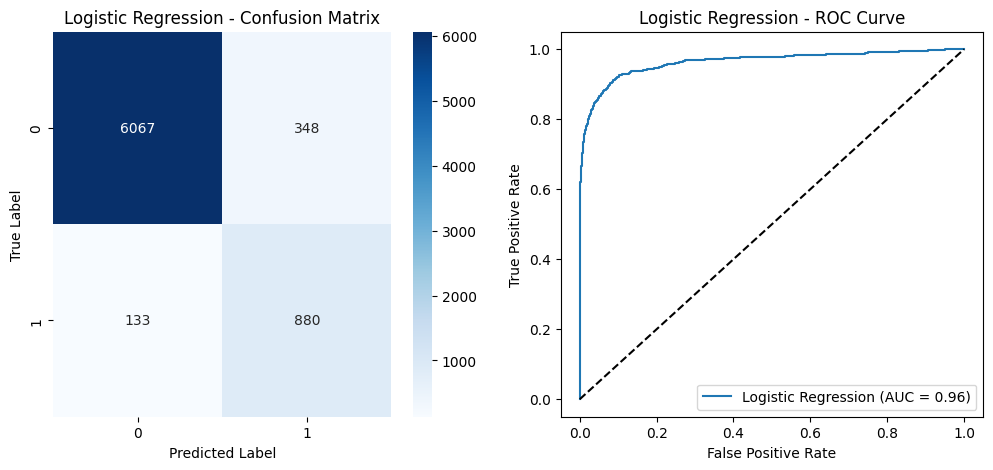


==================== Decision Tree ====================

Train Result
Accuracy Score: 1.0
ROC-AUC: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     25656
           1       1.00      1.00      1.00      4054

    accuracy                           1.00     29710
   macro avg       1.00      1.00      1.00     29710
weighted avg       1.00      1.00      1.00     29710

Confusion Matrix:
 [[25656     0]
 [    0  4054]]

Test Result
Accuracy Score: 0.9498
ROC-AUC: 0.9169
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97      6415
           1       0.78      0.87      0.83      1013

    accuracy                           0.95      7428
   macro avg       0.88      0.92      0.90      7428
weighted avg       0.95      0.95      0.95      7428

Confusion Matrix:
 [[6172  243]
 [ 130  883]]


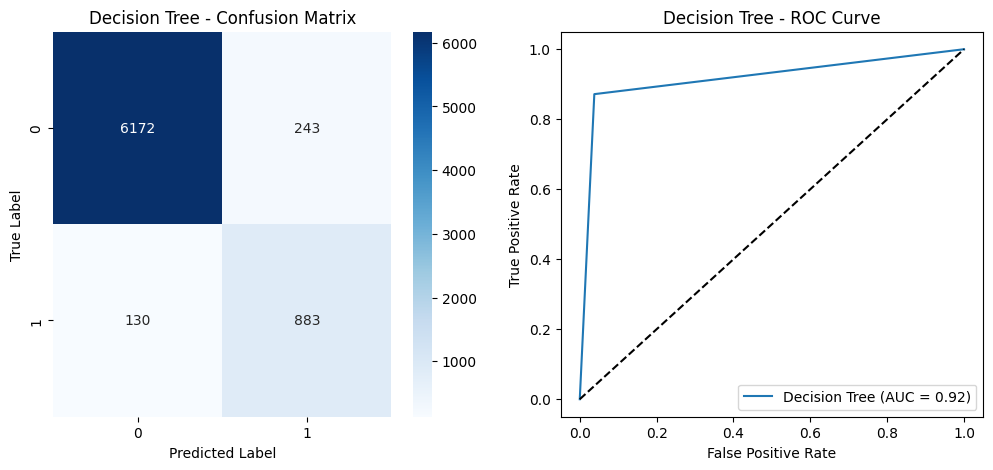


==================== Random Forest ====================

Train Result
Accuracy Score: 1.0
ROC-AUC: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     25656
           1       1.00      1.00      1.00      4054

    accuracy                           1.00     29710
   macro avg       1.00      1.00      1.00     29710
weighted avg       1.00      1.00      1.00     29710

Confusion Matrix:
 [[25656     0]
 [    0  4054]]

Test Result
Accuracy Score: 0.9381
ROC-AUC: 0.9452
Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      6415
           1       0.97      0.57      0.71      1013

    accuracy                           0.94      7428
   macro avg       0.95      0.78      0.84      7428
weighted avg       0.94      0.94      0.93      7428

Confusion Matrix:
 [[6395   20]
 [ 440  573]]


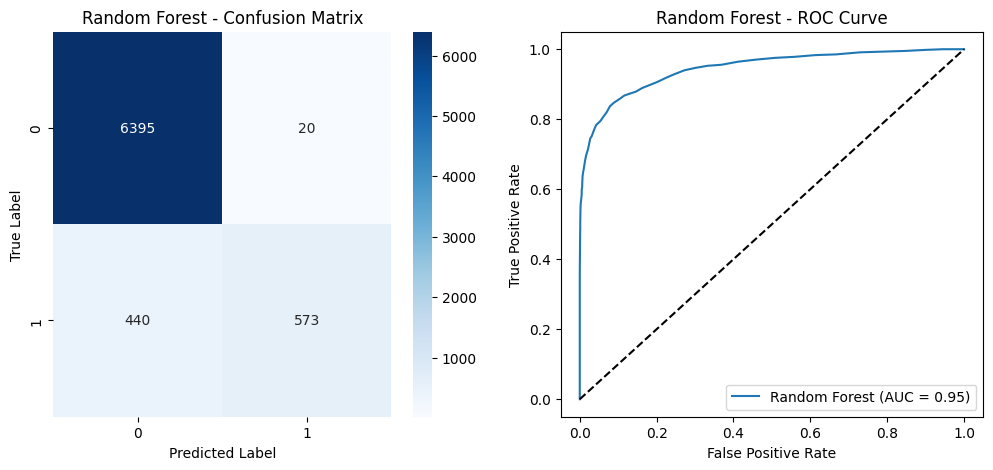


==================== SVM ====================

Train Result
Accuracy Score: 0.9802
ROC-AUC: 0.9931
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     25656
           1       0.95      0.91      0.93      4054

    accuracy                           0.98     29710
   macro avg       0.97      0.95      0.96     29710
weighted avg       0.98      0.98      0.98     29710

Confusion Matrix:
 [[25453   203]
 [  384  3670]]

Test Result
Accuracy Score: 0.9672
ROC-AUC: 0.9746
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      6415
           1       0.92      0.84      0.87      1013

    accuracy                           0.97      7428
   macro avg       0.95      0.91      0.93      7428
weighted avg       0.97      0.97      0.97      7428

Confusion Matrix:
 [[6337   78]
 [ 166  847]]


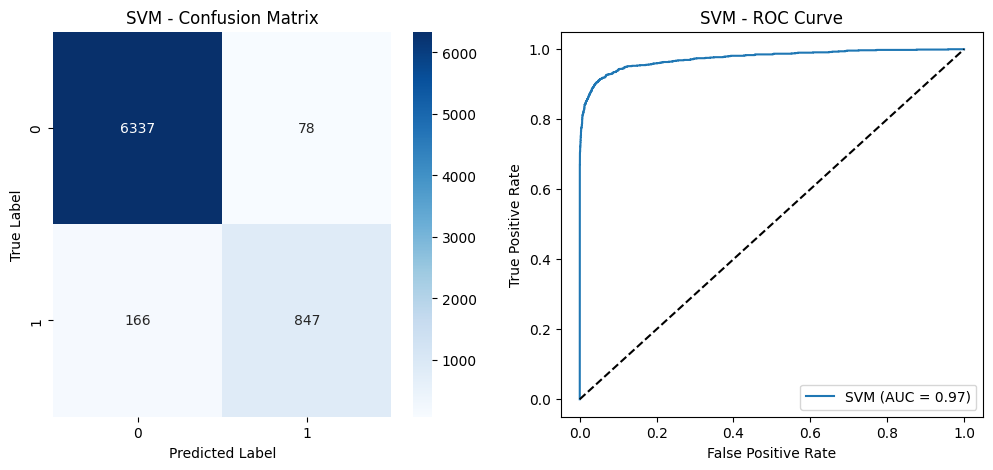


==================== XGBoost ====================


c:\Users\Dian Sukma\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:59:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Train Result
Accuracy Score: 0.9827
ROC-AUC: 0.9954
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     25656
           1       0.99      0.88      0.93      4054

    accuracy                           0.98     29710
   macro avg       0.99      0.94      0.96     29710
weighted avg       0.98      0.98      0.98     29710

Confusion Matrix:
 [[25633    23]
 [  491  3563]]

Test Result
Accuracy Score: 0.974
ROC-AUC: 0.9814
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      6415
           1       0.96      0.85      0.90      1013

    accuracy                           0.97      7428
   macro avg       0.97      0.92      0.94      7428
weighted avg       0.97      0.97      0.97      7428

Confusion Matrix:
 [[6378   37]
 [ 156  857]]


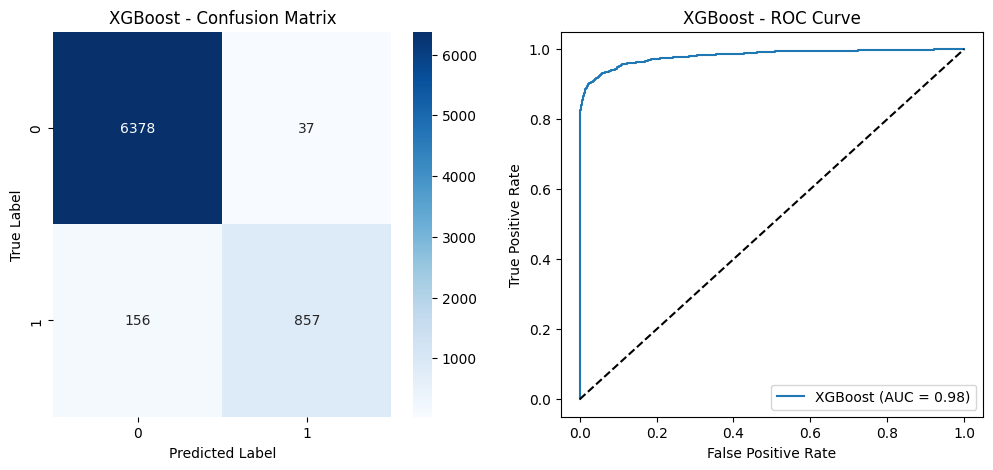


==================== LightGBM ====================
[LightGBM] [Info] Number of positive: 25656, number of negative: 25656
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016081 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25873
[LightGBM] [Info] Number of data points in the train set: 51312, number of used features: 128
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

Train Result
Accuracy Score: 0.9779
ROC-AUC: 0.992
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99     25656
           1       0.98      0.86      0.91      4054

    accuracy                           0.98     29710
   macro avg       0.98      0.93      0.95     29710
weighted avg       0.98      0.98      0.98     29710

Confusion Matrix:
 [[25582    74]
 [  58

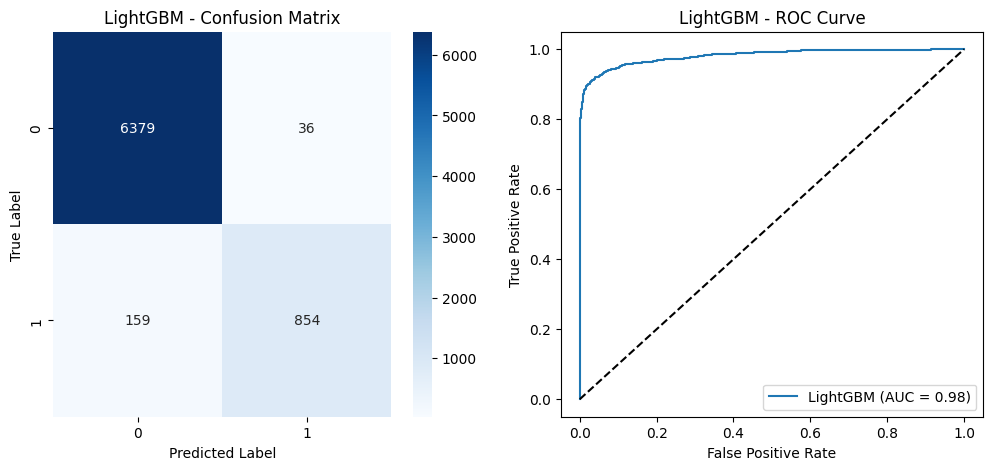

In [44]:
# Pipeline + balancing per model
for name, base_model in ml_models.items():
    pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", base_model)
    ])
    evaluate_and_plot(name, pipeline, X_train, y_train, X_test, y_test)


In [45]:
# Lihat struktur pipeline
print(pipeline.named_steps)         # ringkas: dict dengan nama step
print(pipeline.get_params().keys()) # lengkap: semua parameter

{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['loan_amount', 'annual_income', 'int_rate',
                                  'installment', 'dti', 'total_acc',
                                  'total_payment']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['home_ownership', 'purpose', 'grade',
                                  'verification_status', 'sub_grade',
                            

Sebelum SMOTE: target
0    25656
1     4054
Name: count, dtype: int64
Sesudah SMOTE: target
0    25656
1    25656
Name: count, dtype: int64


c:\Users\Dian Sukma\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7244 - loss: 0.5097 - val_accuracy: 0.9503 - val_loss: 0.1645
Epoch 2/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9113 - loss: 0.2217 - val_accuracy: 0.9526 - val_loss: 0.1446
Epoch 3/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9371 - loss: 0.1587 - val_accuracy: 0.9612 - val_loss: 0.1198
Epoch 4/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9518 - loss: 0.1277 - val_accuracy: 0.9562 - val_loss: 0.1255
Epoch 5/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9563 - loss: 0.1123 - val_accuracy: 0.9653 - val_loss: 0.1053
Epoch 6/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9624 - loss: 0.1020 - val_accuracy: 0.9672 - val_loss: 0.1032
Epoch 7/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9630 - loss: 0.0920 - val_accuracy: 0.9624 - val_loss: 0.1115
Epoch 8/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9703 - loss: 0.0806 - val_accuracy: 0.

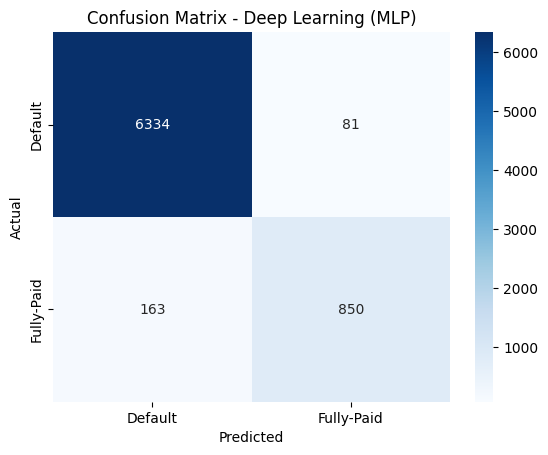

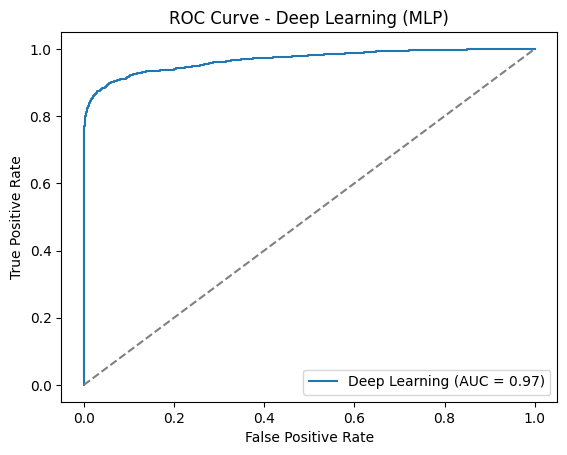

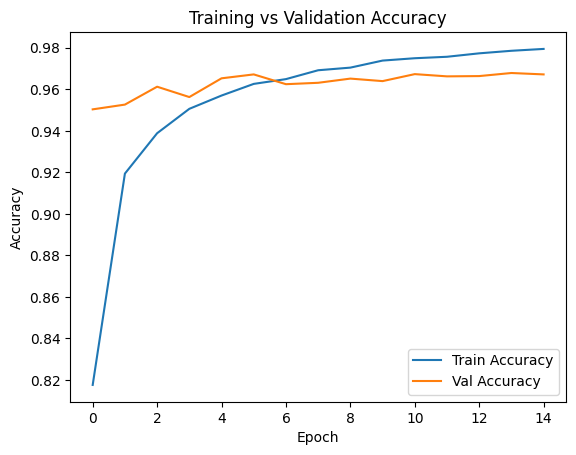

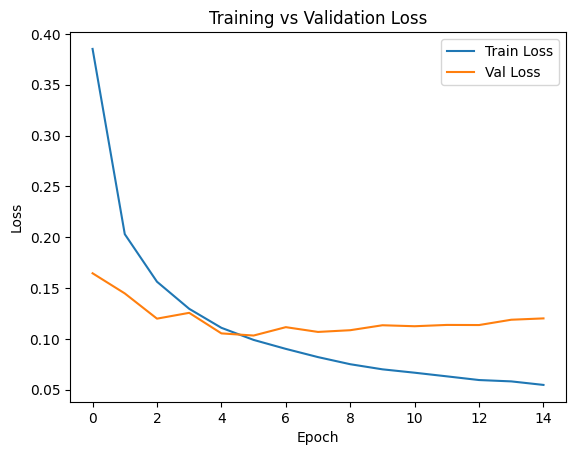

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, models as keras_models



# ====== Preprocessing + Balancing ======
# Preprocess features
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Balancing dengan SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)

print("Sebelum SMOTE:", y_train.value_counts())
print("Sesudah SMOTE:", y_train_bal.value_counts())

# ====== Build Model ======
def build_dl_model(input_dim):
    model = keras_models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dl_model = build_dl_model(X_train_bal.shape[1])

# ====== Training ======
history = dl_model.fit(
    X_train_bal, y_train_bal,
    validation_data=(X_test_prep, y_test),
    epochs=15,
    batch_size=256,
    verbose=1
)

# ====== Evaluasi ======
# Prediksi probabilitas
y_pred_proba = dl_model.predict(X_test_prep).ravel()
y_pred_class = (y_pred_proba >= 0.5).astype(int)

# Classification Report
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_class))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Default","Fully-Paid"],
            yticklabels=["Default","Fully-Paid"])
plt.title("Confusion Matrix - Deep Learning (MLP)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
auc = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f"Deep Learning (AUC = {auc:.2f})")
plt.plot([0,1],[0,1],"--",color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Deep Learning (MLP)")
plt.legend()
plt.show()

# Learning Curve (opsional)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
